# 04d — Road Network Data Preparation

This notebook explores and cleans the OpenStreetMap road network and groups road types into broader functional categories.

**Input**
- OpenStreetMap road-network data for Germany.
- Building data for coordinate-reference alignment.

**Output**
- Cleaned and categorized road-network data.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from shapely.geometry import box
import os
import sys




ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

BUILDING_FILE = os.path.join(DATA_DIR, 'processed', 'germany_buildings_classified_stage1.parquet')
ROAD_FILE = os.path.join(DATA_DIR, 'interim', 'germany_roads.parquet')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [2]:
print("Loading Germany Landuse Data...")
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
gdf_roads = gpd.read_parquet(ROAD_FILE)

print("Data loaded successfully!")

Loading Germany Landuse Data...
Data loaded successfully!


In [3]:
FAKE_NULLS = {'nan', 'NaN', 'None', 'none', '', ' ', 'NULL', 'null'}

def replace_fake_nulls(gdf, name='dataset'):
    replaced = 0
    for col in gdf.select_dtypes(include=['object']).columns:
        if col == 'geometry':
            continue
        mask = gdf[col].isin(FAKE_NULLS)
        n = mask.sum()
        if n > 0:
            gdf.loc[mask, col] = np.nan
            replaced += n
    print(f'[{name}] Replaced {replaced:,} fake-null strings with np.nan')
    return gdf

gdf_roads = replace_fake_nulls(gdf_roads, 'roads')


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.
[roads] Replaced 257,432,825 fake-null strings with np.nan


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
print(gdf_roads.geometry.geom_type.value_counts().to_string())


MultiLineString    8287450


In [6]:
gdf_roads.head()

,access,area,bicycle,bicycle_road,bridge,busway,cycleway,est_width,foot,footway,highway,int_ref,junction,lanes,lit,maxspeed,motorcar,motorroad,motor_vehicle,name,oneway,overtaking,path,passing_places,psv,ref,service,segregated,sidewalk,smoothness,surface,tracktype,tunnel,turn,width,id,timestamp,version,tags,osm_type,geometry,length
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,NaN,NaN,NaN,yes,30,NaN,NaN,NaN,Eigenheimstraße,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,asphalt,NaN,NaN,NaN,NaN,92,1757511664,11,"{""visible"":false,""maxweight"":""3.5"",""maxweight:...",way,"MULTILINESTRING ((13.73698 51.01663, 13.73752 ...",386.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,NaN,NaN,NaN,yes,30,NaN,NaN,NaN,Eigenheimberg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,asphalt,NaN,NaN,NaN,NaN,93,1757511664,10,"{""visible"":false,""maxweight"":""3.5"",""maxweight:...",way,"MULTILINESTRING ((13.73939 51.01669, 13.73967 ...",89.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tertiary,NaN,roundabout,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,separate,NaN,asphalt,NaN,NaN,NaN,NaN,99,1750448678,23,"{""visible"":false,""cycleway:right"":""no"",""lane_m...",way,"MULTILINESTRING ((11.36639 48.17411, 11.36643 ...",36.0
3,NaN,NaN,use_sidepath,NaN,NaN,NaN,NaN,NaN,use_sidepath,NaN,secondary,NaN,roundabout,NaN,yes,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,asphalt,NaN,NaN,NaN,NaN,100,1773766376,22,"{""visible"":false,""lane_markings"":""no"",""tmc"":""D...",way,"MULTILINESTRING ((11.33038 48.18011, 11.33033 ...",98.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,Altmockritz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103,1757511664,9,"{""visible"":false,""source:maxspeed"":""sign""}",way,"MULTILINESTRING ((13.74127 51.01615, 13.74149 ...",98.0


In [7]:
VALID_ROAD_GEOM = {'LineString', 'MultiLineString'}

print('Initial geometry types:')
print(gdf_roads.geometry.geom_type.value_counts().to_string())

before = len(gdf_roads)
gdf_roads = gdf_roads[gdf_roads.geometry.geom_type.isin(VALID_ROAD_GEOM)].copy()
after_geo = len(gdf_roads)

print(f'\nRows before : {before:,}')
print(f'Rows after  : {after_geo:,}')
print(f'Dropped     : {before - after_geo:,}')

Initial geometry types:
MultiLineString    8287450

Rows before : 8,287,450
Rows after  : 8,287,450
Dropped     : 0


In [8]:
invalid_before = (~gdf_roads.geometry.is_valid).sum()
empty_before   = gdf_roads.geometry.is_empty.sum()

print(f'Invalid geometries: {invalid_before:,}')
print(f'Empty geometries  : {empty_before:,}')

# Fix invalids
invalid_mask = ~gdf_roads.geometry.is_valid
gdf_roads.loc[invalid_mask, 'geometry'] = (
    gdf_roads.loc[invalid_mask, 'geometry'].buffer(0)
)

# Drop anything still broken
drop_mask = (~gdf_roads.geometry.is_valid) | gdf_roads.geometry.is_empty
gdf_roads = gdf_roads[~drop_mask].copy()
after_invalid = len(gdf_roads)

print(f'Remaining invalid : {(~gdf_roads.geometry.is_valid).sum():,}')
print(f'Rows remaining    : {after_invalid:,}')

Invalid geometries: 672
Empty geometries  : 0
Remaining invalid : 0
Rows remaining    : 8,286,778


In [9]:
TOTAL  = len(gdf_roads)
ID_COL = 'id'

print(f'Total rows        : {TOTAL:,}')
print(f'Non-null IDs      : {gdf_roads[ID_COL].notna().sum():,}')
print(f'Unique IDs        : {gdf_roads[ID_COL].nunique():,}')
print(f'Duplicate IDs     : {TOTAL - gdf_roads[ID_COL].nunique():,}')

dupes = gdf_roads[gdf_roads[ID_COL].duplicated(keep=False)].sort_values(ID_COL)
print(f'\nOSM types in duplicates:')
print(dupes['osm_type'].value_counts())

Total rows        : 8,286,778
Non-null IDs      : 8,286,778
Unique IDs        : 8,286,778
Duplicate IDs     : 0

OSM types in duplicates:
Series([], Name: count, dtype: int64)


In [10]:
ROAD_GROUPS = {
    'major_road': ['motorway', 'motorway_link', 'trunk', 'trunk_link', 'primary', 'primary_link'],
    'secondary_road': ['secondary', 'secondary_link', 'tertiary', 'tertiary_link'], 
    'residential_road': ['residential', 'living_street'],
    'service_road': ['service'],
    'rural_track': ['track', 'unclassified', 'trrack'], 
    'pedestrian_zone': ['pedestrian', 'footway', 'path', 'cycleway', 'steps', 'bridleway', 'footpath', 'fooway']
}

# Flatten the map for easy lookup
highway_to_group = {
    tag: group
    for group, tags in ROAD_GROUPS.items()
    for tag in tags
}

gdf_roads['road_category'] = gdf_roads['highway'].map(highway_to_group)

# Check what's still unmapped
unmapped = gdf_roads[gdf_roads['road_category'].isna()]
print(f"Unmapped rows : {len(unmapped):,}")
print(unmapped['highway'].value_counts().head(20))


Unmapped rows : 10,260
highway
bus_stop          4619
rest_area         2154
busway             835
services           728
traffic_island     404
construction       307
road               280
via_ferrata        219
raceway            114
emergency_bay      100
no                  79
crossing            61
ladder              59
planned             45
corridor            32
escape              30
proposed            28
passing_place       22
traffic_sign        19
yes                 18
Name: count, dtype: int64


In [11]:
before_noise_drop = len(gdf_roads)
# Drop unmapped — these are noise (bus stops, traffic signs etc.)
gdf_roads = gdf_roads[gdf_roads['road_category'].notna()].copy()
print(f"Kept : {len(gdf_roads):,} of {before_noise_drop:,}")

Kept : 8,276,518 of 8,286,778


/tmp/ipykernel_1063019/2790760664.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stages, y=counts, palette='crest', edgecolor='black', ax=ax)


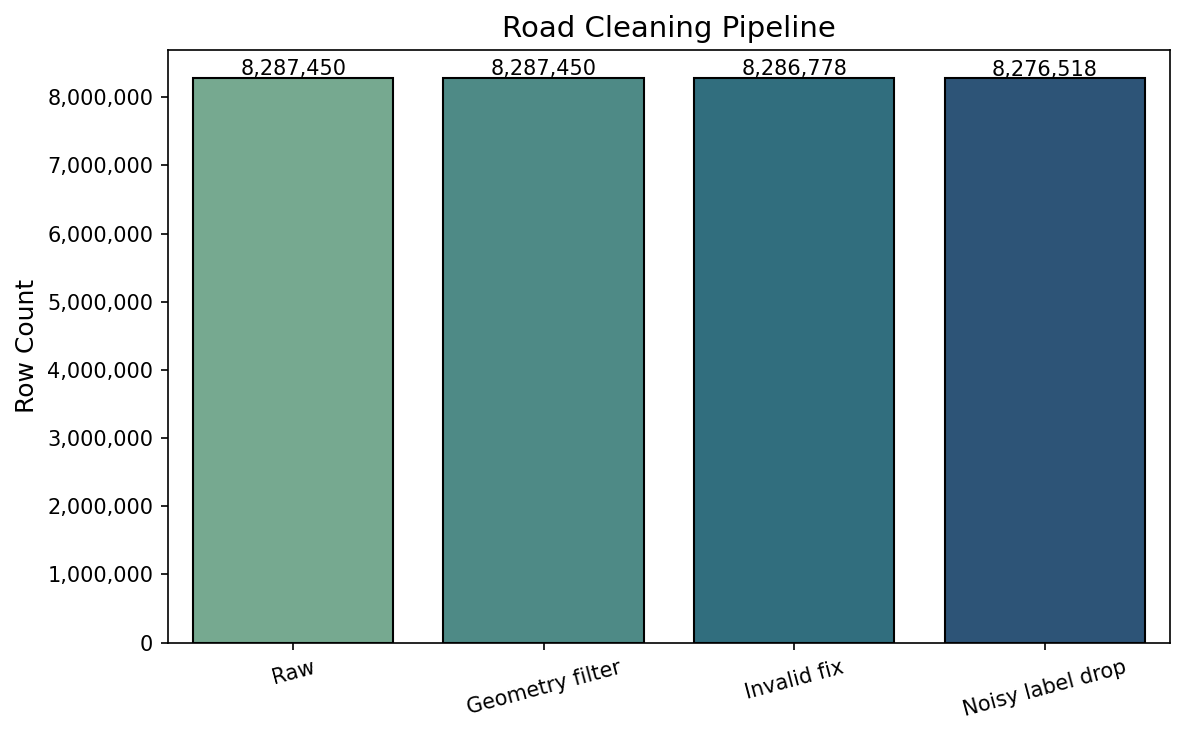

In [12]:
# Cleaning pipeline summary plot — same as your landuse notebook
stages = ['Raw', 'Geometry filter', 'Invalid fix', 'Noisy label drop']
counts = [before, after_geo, after_invalid, len(gdf_roads)]

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
sns.barplot(x=stages, y=counts, palette='crest', edgecolor='black', ax=ax)
ax.set_title('Road Cleaning Pipeline', fontsize=14)
ax.set_ylabel('Row Count', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, c in enumerate(counts):
    ax.text(i, c + max(counts)*0.005, f'{c:,}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [13]:
print("Category breakdown:")
print(gdf_roads['road_category'].value_counts(dropna=False).to_string())

Category breakdown:
road_category
service_road        3946077
residential_road    2187325
secondary_road      1008466
rural_track          689010
major_road           426521
pedestrian_zone       19119


In [14]:
# For each category, show which raw highway tags it contains
print("RAW TAG BREAKDOWN PER CATEGORY")
print("=" * 50)

for cat in ROAD_GROUPS.keys():
    subset = gdf_roads[gdf_roads['road_category'] == cat]
    tag_counts = subset['highway'].value_counts()
    
    print(f"\n{cat.upper()} — {len(subset):,} roads")
    print(tag_counts.to_string())
    print("-" * 30)

RAW TAG BREAKDOWN PER CATEGORY

MAJOR_ROAD — 426,521 roads
highway
primary          241139
motorway          70229
motorway_link     43214
trunk             33264
trunk_link        21549
primary_link      17126
------------------------------

SECONDARY_ROAD — 1,008,466 roads
highway
secondary         508155
tertiary          478554
secondary_link     13914
tertiary_link       7843
------------------------------

RESIDENTIAL_ROAD — 2,187,325 roads
highway
residential      2013614
living_street     173711
------------------------------

SERVICE_ROAD — 3,946,077 roads
highway
service    3946077
------------------------------

RURAL_TRACK — 689,010 roads
highway
unclassified    417689
track           271318
trrack               3
------------------------------

PEDESTRIAN_ZONE — 19,119 roads
highway
path          10837
footway        4892
pedestrian     2094
cycleway        943
steps           278
bridleway        63
fooway            9
footpath          3
------------------------------


In [15]:
# Compute lengths in metres (need metric CRS)
gdf_roads_m = gdf_roads.to_crs(epsg=3035)
gdf_roads_m['length_m'] = gdf_roads_m.geometry.length

print("LENGTH DISTRIBUTION PER CATEGORY (metres)")
print("=" * 50)
length_stats = (
    gdf_roads_m.groupby('road_category')['length_m']
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(1)
)
print(length_stats.to_string())

LENGTH DISTRIBUTION PER CATEGORY (metres)
                      count   mean    std  min    5%   25%    50%    75%     95%      max
road_category                                                                            
major_road         426521.0  189.1  380.3  0.4  11.6  34.0   74.2  182.6   737.4   9913.9
pedestrian_zone     19119.0  175.8  307.1  0.2   5.6  25.4   71.3  193.3   688.2   5380.5
residential_road  2187325.0  147.4  155.1  0.1  11.1  46.5  102.3  195.6   431.3   5538.7
rural_track        689010.0  373.5  478.7  0.1  11.3  63.1  210.4  498.7  1288.3  23304.4
secondary_road    1008466.0  203.8  383.2  0.2   9.7  29.2   68.7  200.6   875.0  13964.4
service_road      3946077.0   71.2  118.4  0.1   7.1  20.7   42.0   79.3   222.6  19337.0


In [16]:
# Flag suspiciously short roads (< 1m — likely bad geometry)
too_short = gdf_roads_m[gdf_roads_m['length_m'] < 1]
print(f"\nRoads shorter than 1m : {len(too_short):,}")
print(too_short['highway'].value_counts().head(10))

# Flag suspiciously long roads (> 50km — likely bad geometry)  
too_long = gdf_roads_m[gdf_roads_m['length_m'] > 50_000]
print(f"\nRoads longer than 50km : {len(too_long):,}")
print(too_long['highway'].value_counts().head(10))


Roads shorter than 1m : 1,566
highway
service          904
residential      282
secondary         82
tertiary          81
unclassified      53
primary           46
living_street     31
track             29
path              18
footway           16
Name: count, dtype: int64

Roads longer than 50km : 0
Series([], Name: count, dtype: int64)


/tmp/ipykernel_1063019/72142444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1063019/72142444.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


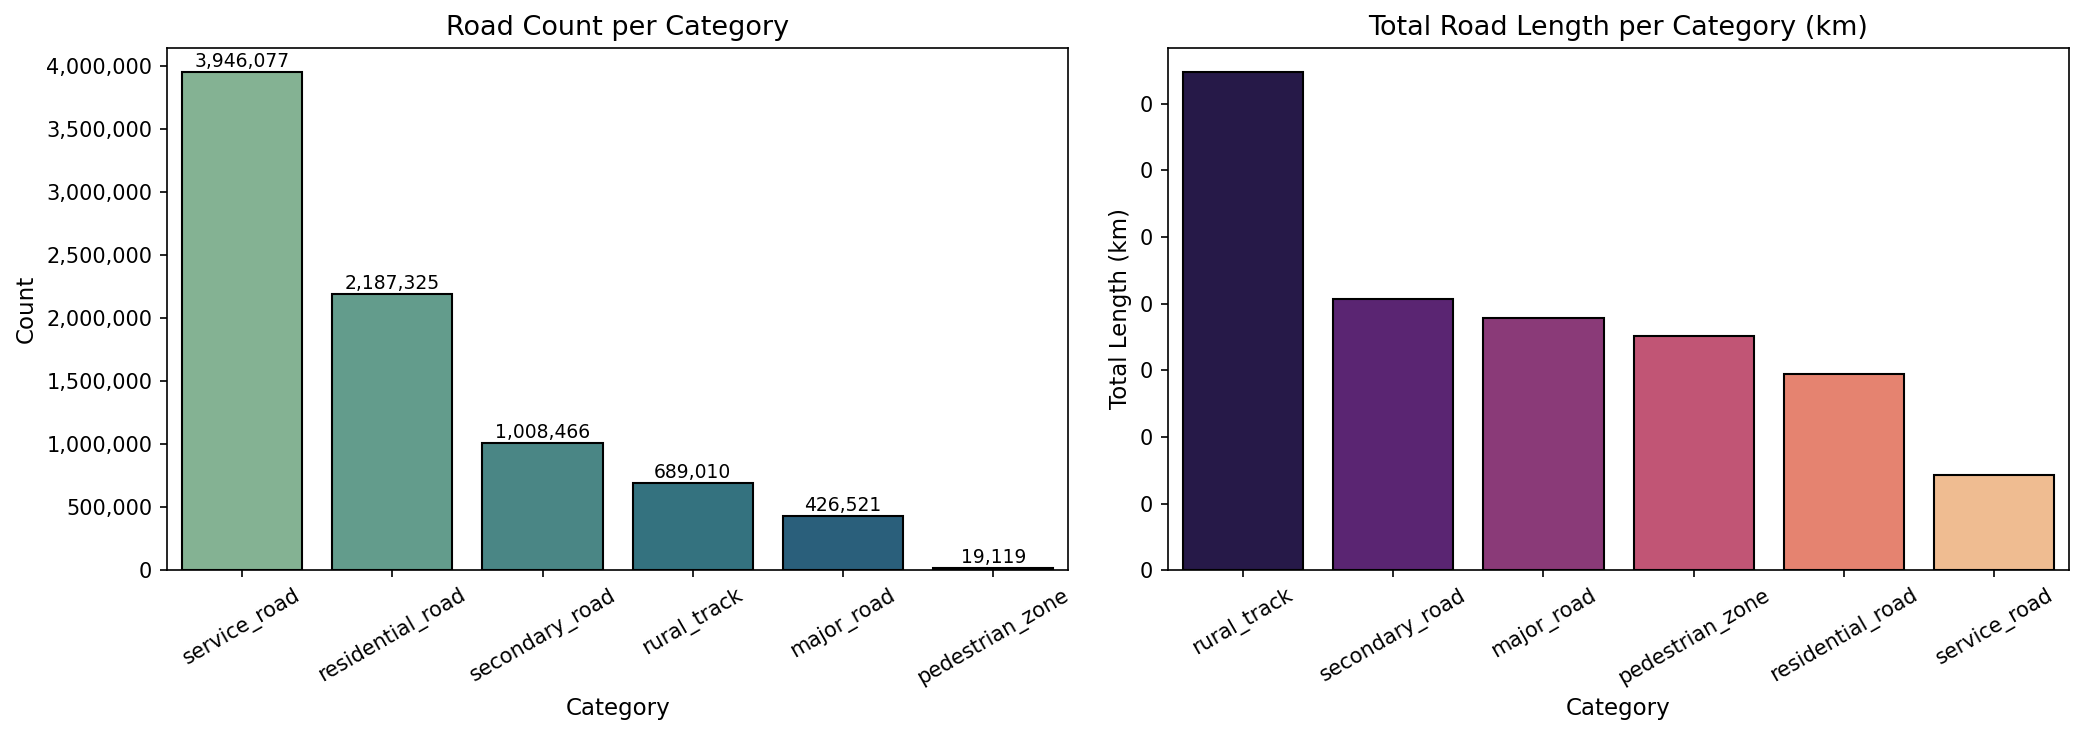

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Left — count per category
cat_counts = gdf_roads['road_category'].value_counts()
sns.barplot(
    x=cat_counts.index, y=cat_counts.values,
    palette='crest', edgecolor='black', ax=axes[0]
)
axes[0].set_title('Road Count per Category', fontsize=13)
axes[0].set_xlabel('Category', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cat_counts):
    axes[0].text(i, v + cat_counts.max()*0.01,
                 f'{v:,}', ha='center', fontsize=9)

# Right — total road length per category (km)
length_by_cat = (
    gdf_roads_m.groupby('road_category')['length_m']
    .mean()
    .sort_values(ascending=False)
    / 1000  # convert to km
)
sns.barplot(
    x=length_by_cat.index, y=length_by_cat.values,
    palette='magma', edgecolor='black', ax=axes[1]
)
axes[1].set_title('Total Road Length per Category (km)', fontsize=13)
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Total Length (km)', fontsize=11)
axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Roads in sample area: 3,285
road_category
service_road        1591
residential_road     934
secondary_road       579
major_road           173
pedestrian_zone        8
Name: count, dtype: int64


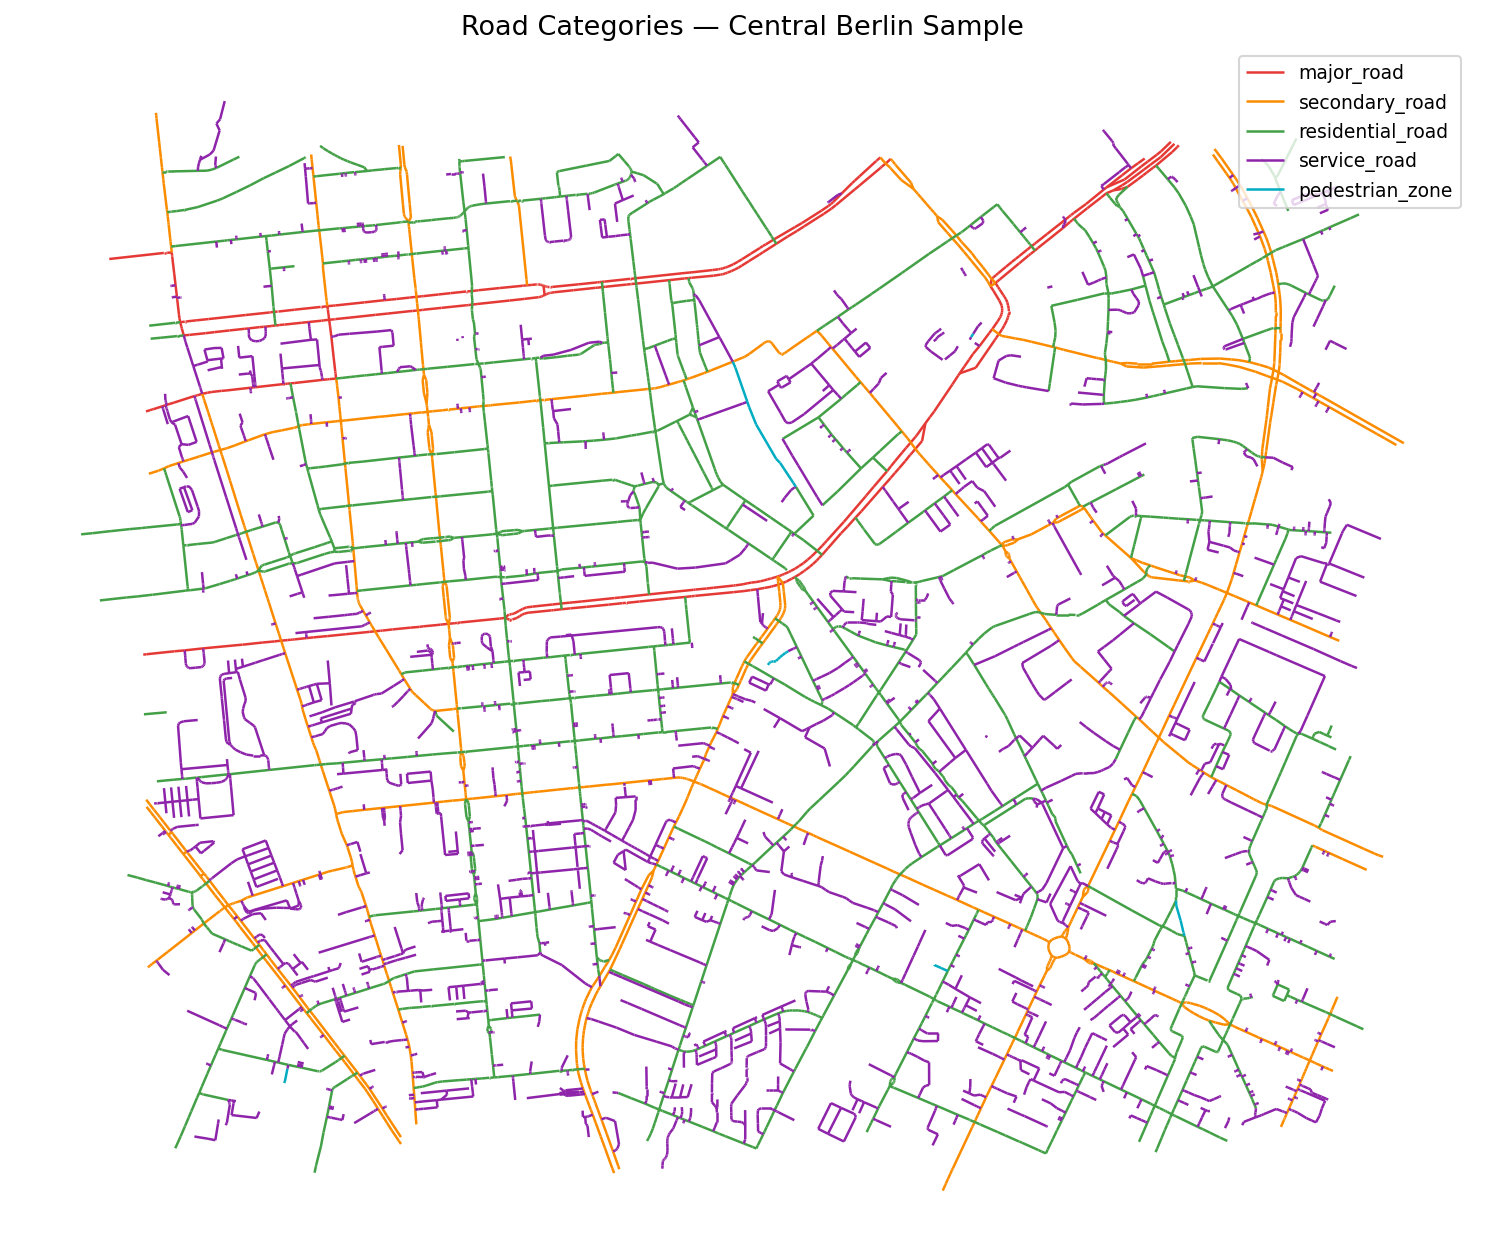

In [18]:
#  central Berlin

berlin_bbox = box(13.38, 52.50, 13.42, 52.52)  # lon/lat

roads_berlin = gdf_roads[
    gdf_roads.geometry.intersects(berlin_bbox)
].copy()

print(f"Roads in sample area: {len(roads_berlin):,}")
print(roads_berlin['road_category'].value_counts())

# Plot
CATEGORY_COLORS = {
    'major_road'      : '#E53935',   # red
    'secondary_road'  : '#FB8C00',   # orange
    'residential_road'     : '#43A047',   # green
    'service_road'    : '#8E24AA',   # purple
    'rural_track'     : '#6D4C41',   # brown
    'pedestrian_zone' : '#00ACC1',   # cyan
}

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

for cat, color in CATEGORY_COLORS.items():
    subset = roads_berlin[roads_berlin['road_category'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=1.2, label=cat)

ax.set_title('Road Categories — Central Berlin Sample', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [19]:
# Drop short roads
roads_clean = gdf_roads_m[gdf_roads_m['length_m'] >= 1].copy()

roads_slim = roads_clean[['id', 'geometry', 'highway', 'road_category']].copy()


In [20]:
len(roads_slim)

8274952

In [21]:
roads_slim = roads_slim.to_crs(gdf_bldg.crs)

In [22]:
roads_slim.crs.to_string()

'EPSG:4326'

In [23]:
roads_slim.to_parquet(
    os.path.join(DATA_DIR, 'processed', 'germany_roads_mapped.parquet'),
    index=False
)
print(f"Saved {len(roads_slim):,} roads")

Saved 8,274,952 roads


In [24]:
roads_slim.head()

,id,geometry,highway,road_category
0,92,"MULTILINESTRING ((13.73698 51.01663, 13.73752 ...",residential,residential_road
1,93,"MULTILINESTRING ((13.73939 51.01669, 13.73967 ...",residential,residential_road
2,99,"MULTILINESTRING ((11.36639 48.17411, 11.36643 ...",tertiary,secondary_road
3,100,"MULTILINESTRING ((11.33038 48.18011, 11.33033 ...",secondary,secondary_road
4,103,"MULTILINESTRING ((13.74127 51.01615, 13.74149 ...",residential,residential_road
